# Binary Search Tree

**Domain:** `data-structures-algorithms`

Imagine a filing cabinet where every folder is allowed at most **two**
sub-folders directly inside it: one on the left, one on the right. When you
file a new document labeled with a number, you follow one simple rule at
every folder you visit: **smaller goes left, bigger goes right.** Start at
the top folder, compare your number to its label, step into the left or
right sub-folder accordingly, and repeat -- comparing, then stepping down
one level -- until you find an empty slot to file the new document, or you
find the folder that already has that exact label.

That's it. That's a **binary search tree** (BST): a "20 questions" game
where every question is "is my number smaller or bigger than this one?",
and each answer eliminates an entire branch of possibilities at once,
because you *never* have to search the folders on the wrong side.

Finding a document later works exactly the same way: start at the top,
compare, step left or right, repeat -- and either you land on the label
you're after, or you run out of folders and know for certain it was never
filed. No need to open every folder in the cabinet.

By the end of this tutorial you'll be able to: explain why a BST keeps
values in sorted order automatically, prove why searching/inserting/
deleting all cost time proportional to the tree's *height* rather than its
*size*, understand why that height can blow up to the size of the whole
tree in the worst case (and why that motivates *self-balancing* trees like
AVL and red-black trees), and run a real, compiled Java implementation
that reports its own height, node count, and full shape after real
insertions and deletions.

## The idea, intuitively

**Every node holds one value, plus (at most) two pointers: a left child and
a right child.** The whole tree obeys one rule everywhere, not just at the
root:

- Everything in a node's **left** subtree is **smaller** than the node.
- Everything in a node's **right** subtree is **bigger** than the node.

**Inserting** a value: start at the root and walk down, going left when
your value is smaller than the current node and right when it's bigger,
until you fall off the tree (hit an empty spot) -- that's where the new
node goes.

**Searching** for a value: exactly the same walk. If you land on a node
whose value matches, you found it. If you fall off the tree first, it's
not there.

Let's hand-trace it. Insert these 8 numbers **one at a time**, in this
order, always starting from the root:

```
50, 30, 70, 20, 40, 60, 80, 35
```

- `50`: tree is empty &rarr; becomes the **root**.
- `30`: `30 < 50` &rarr; go left of 50 &rarr; empty &rarr; **left child of 50**.
- `70`: `70 > 50` &rarr; go right of 50 &rarr; empty &rarr; **right child of 50**.
- `20`: `20 < 50` &rarr; left; `20 < 30` &rarr; left &rarr; empty &rarr; **left child of 30**.
- `40`: `40 < 50` &rarr; left; `40 > 30` &rarr; right &rarr; empty &rarr; **right child of 30**.
- `60`: `60 > 50` &rarr; right; `60 < 70` &rarr; left &rarr; empty &rarr; **left child of 70**.
- `80`: `80 > 50` &rarr; right; `80 > 70` &rarr; right &rarr; empty &rarr; **right child of 70**.
- `35`: `35 < 50` &rarr; left; `35 > 30` &rarr; right; `35 < 40` &rarr; left &rarr; empty &rarr; **left child of 40**.

The resulting shape:

```
                 50
               /    \
             30      70
            /  \    /  \
          20    40 60   80
               /
             35
```

Notice you never had to compare `20` against `70`, `60`, or `80` -- the
very first comparison (`20 < 50`) ruled out that entire right half of the
tree in one step. That's the whole reason a BST is fast: **every
comparison throws away a whole branch, not just one element.**

Here's that identical comparison logic as a tiny, runnable snippet -- a
plain Python dictionary standing in for a "node" (`{"value", "left",
"right"}`), just to make the idea concrete before we bring in the real
Java implementation:

In [1]:
def toy_insert(node, value):
    if node is None:
        return {"value": value, "left": None, "right": None}
    if value < node["value"]:
        node["left"] = toy_insert(node["left"], value)
    elif value > node["value"]:
        node["right"] = toy_insert(node["right"], value)
    return node

def toy_search(node, value):
    if node is None:
        return False
    if value == node["value"]:
        return True
    return toy_search(node["left"], value) if value < node["value"] else toy_search(node["right"], value)

def toy_inorder(node, out):
    if node is None:
        return
    toy_inorder(node["left"], out)
    out.append(node["value"])
    toy_inorder(node["right"], out)

values = [50, 30, 70, 20, 40, 60, 80, 35]

toy_tree = None
for v in values:
    toy_tree = toy_insert(toy_tree, v)

out = []
toy_inorder(toy_tree, out)
print("inserted in this order: ", values)
print("in-order traversal:     ", out)
print("search(35):", toy_search(toy_tree, 35))
print("search(99):", toy_search(toy_tree, 99))
assert out == sorted(values)
print("\nin-order traversal produced sorted order for free -- no sorting step needed.")

inserted in this order:  [50, 30, 70, 20, 40, 60, 80, 35]
in-order traversal:      [20, 30, 35, 40, 50, 60, 70, 80]
search(35): True
search(99): False

in-order traversal produced sorted order for free -- no sorting step needed.


**Takeaway:** a BST isn't "a tree that happens to be sorted" -- the
insertion rule (*smaller left, bigger right, everywhere*) is exactly what
*makes* an in-order walk (left subtree, then the node, then right subtree)
visit every value in ascending order. Sorted order is a side effect of the
structure, not something computed afterward.

## Going deeper: the formal definition

### The BST invariant

A binary tree is a **binary search tree** if, for every node $x$ in the
tree:

$$
\forall\, y \in \text{left-subtree}(x):\ y.\text{value} < x.\text{value}
\qquad\text{and}\qquad
\forall\, z \in \text{right-subtree}(x):\ z.\text{value} > x.\text{value}
$$

This must hold at **every** node, not just the root -- it's what lets you
throw away an entire branch after a single comparison, no matter where in
the tree you are. (Our implementation below disallows duplicate values,
so these are strict inequalities; some implementations allow duplicates by
convention, e.g. always routing equal values right, at the cost of a
slightly weaker invariant.)

### Why in-order traversal produces sorted output

**Claim:** an in-order traversal (visit left subtree, then the node, then
right subtree) of any BST outputs its values in strictly ascending order.

**Proof, by induction on the number of nodes $n$ in the subtree:**

*Base case* ($n = 0$ or $n = 1$): an empty subtree produces the empty
sequence, and a single node produces a one-element sequence -- both
trivially sorted.

*Inductive step:* assume the claim holds for every subtree with fewer than
$n$ nodes. Take a subtree rooted at $x$ with $n$ nodes. Its in-order
traversal is, by definition:

$$
\text{inorder}(\text{left}(x)) \;\Vert\; [x.\text{value}] \;\Vert\; \text{inorder}(\text{right}(x))
$$

Both `left(x)` and `right(x)` have fewer than $n$ nodes, so by the
inductive hypothesis each of `inorder(left(x))` and `inorder(right(x))` is
individually sorted ascending. By the BST invariant, **every** value in
`left(x)` is `< x.value`, and **every** value in `right(x)` is
`> x.value`. So the concatenation -- sorted-left, then $x$, then
sorted-right -- is itself sorted ascending, with no boundary violation at
either junction. $\blacksquare$

### Complexity: it's all about height, not size

Search and insert both do the *same* walk: start at the root, and at each
node do $O(1)$ work (one comparison) before moving to exactly one child.
The walk ends when you either find the value or fall off the tree, and
either way, **the number of nodes you visit is bounded by the number of
edges on the longest root-to-leaf path** -- the tree's **height** $h$.

$$
\text{search, insert} = O(h)
$$

Deletion (detailed below) is also $O(h)$: locating the node to delete is
one root-to-leaf-bounded walk, and the trickiest case adds at most one
more walk bounded by a subtree's height, which is itself $\le h$.

**This is the single most important fact about BSTs, and it cuts both
ways:**

- If the tree stays **balanced** -- each subtree roughly half the size of
  its parent -- then $h = \Theta(\log n)$, because the size halves at
  every level, the same argument that gives binary search on a sorted
  array its $O(\log n)$ bound.
- If the tree **degenerates**, $h$ can be $\Theta(n)$. The clearest way to
  see this: insert values that are **already sorted** (`1, 2, 3, 4, ...`).
  Every new value is bigger than everything already in the tree, so it
  always becomes the right child of the current maximum -- the tree turns
  into a straight line, identical in shape (and search cost) to a linked
  list.

$$
\text{plain BST cost} = O(h) = \begin{cases} \Theta(\log n) & \text{tree stays balanced} \\ \Theta(n) & \text{worst case (e.g. sorted insertion order)} \end{cases}
$$

This gap -- guaranteed-fast vs. can-degrade-to-linear on unlucky input --
is exactly why **self-balancing binary search trees** (AVL trees,
red-black trees) exist: they add extra bookkeeping to every insert/delete
so the tree *provably* never drifts far from balanced, guaranteeing
$h = \Theta(\log n)$ regardless of insertion order. A plain BST, as built
here, makes no such guarantee -- we'll measure that gap directly in the
Visuals section below.

### Deletion: the three cases

Deletion is the trickiest BST operation to get right, because removing a
node can't be allowed to break the invariant for the rest of the tree.
There are exactly three shapes the node-to-delete can have:

**Case 1 -- the node is a leaf (no children).** Just remove it: set the
parent's pointer to that child to `null`. Nothing else in the tree
referenced this node as an ancestor for ordering purposes, so the
invariant is trivially preserved everywhere else.

**Case 2 -- the node has exactly one child.** Splice the child up into the
node's place: the parent now points directly at the (former) grandchild
subtree. This preserves the invariant because that subtree's values were
already constrained to be consistent with every one of the deleted node's
ancestors (that's *why* they were valid children of the deleted node in
the first place) -- removing one link in the chain doesn't change any of
those transitive bounds.

**Case 3 -- the node has two children.** You can't just delete it (which
child inherits its spot?) or splice up both children (a node has only one
parent slot). The standard fix: replace the node's *value* with its
**in-order successor** -- the smallest value in its right subtree -- then
delete the successor's original node instead (which is now guaranteed to
be case 1 or case 2; see below).

*Why this preserves the invariant:* let $x$ be the node being deleted and
$s$ be its in-order successor (the leftmost node of $x$'s right subtree).

- $s$ is a member of $x$'s right subtree, so by the BST invariant applied
  at $x$: $s > $ everything in $x$'s **left** subtree. So overwriting
  $x.\text{value}$ with $s$ keeps the left-subtree relationship intact.
- $s$ is the *minimum* of $x$'s right subtree (that's what "leftmost"
  means), so $s \le$ everything else remaining in that right subtree
  (strictly `<`, since duplicates aren't allowed here). So the
  right-subtree relationship holds too.
- $s$ itself, being the leftmost node of a subtree, **has no left child**
  by definition -- if it did, that child would be even smaller and
  *it* would be the leftmost node instead. So deleting $s$ from its
  original position is always case 1 (if $s$ has no right child either)
  or case 2 (if it does) -- never another case 3. The recursion bottoms
  out in one extra step.

(The mirror-image fix -- replace with the in-order **predecessor**, the
largest value in the left subtree -- is equally correct by the same
argument; different implementations pick one or the other, sometimes
alternating to help keep the tree balanced.)

## Visuals

The plots below are built from the **real, compiled Java implementation**
in [`src/BST.java`](src/BST.java) -- not a hand-drawn mock. We compile it
here with `javac` and drive it with `subprocess`, the same way the
Implementation section does later; we're just pulling that step forward
because the diagrams need real program output to be worth anything.

In [2]:
import subprocess
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

src_dir = pathlib.Path("src")

compile_cmd = ["javac", str(src_dir / "BST.java")]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully -> src/BST.class")

compile return code: 0
compiled successfully -> src/BST.class


In [3]:
# Run the compiled BST program on a list of command strings
# ("I 5" insert, "D 3" delete, "S 8" search), fed one per line on
# stdin. Returns the parsed in-order traversal, height, node count,
# and the full tree structure (value -> (left_value_or_None,
# right_value_or_None)) that BST.java prints after every run.
def run_bst(commands, extra_java_args=None):
    java_cmd = ["java"] + (extra_java_args or []) + ["-cp", str(src_dir), "BST"]
    input_str = "\n".join(commands) + "\n"
    proc = subprocess.run(java_cmd, input=input_str, capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr

    lines = proc.stdout.strip().splitlines()
    result = {"searches": [], "structure": {}}
    i = 0
    while i < len(lines):
        line = lines[i]
        if line.startswith("FOUND") or line.startswith("NOT_FOUND"):
            result["searches"].append(line)
        elif line.startswith("INORDER:"):
            result["inorder"] = [int(x) for x in line[len("INORDER:"):].split()]
        elif line.startswith("HEIGHT:"):
            result["height"] = int(line.split(":")[1])
        elif line.startswith("COUNT:"):
            result["count"] = int(line.split(":")[1])
        elif line == "STRUCTURE:":
            i += 1
            while i < len(lines):
                parts = lines[i].split()
                val = int(parts[0])
                left = None if parts[1] == "NULL" else int(parts[1])
                right = None if parts[2] == "NULL" else int(parts[2])
                result["structure"][val] = (left, right)
                i += 1
            continue
        i += 1
    return result


# The exact 8 numbers from the hand-traced example above.
values = [50, 30, 70, 20, 40, 60, 80, 35]
example = run_bst([f"I {v}" for v in values])

print("in-order traversal:", example["inorder"])
print("height:", example["height"])
print("node count:", example["count"])
assert example["inorder"] == sorted(values)
print("\ncorrectness check passed: matches Python's sorted()")

in-order traversal: [20, 30, 35, 40, 50, 60, 70, 80]
height: 3
node count: 8

correctness check passed: matches Python's sorted()


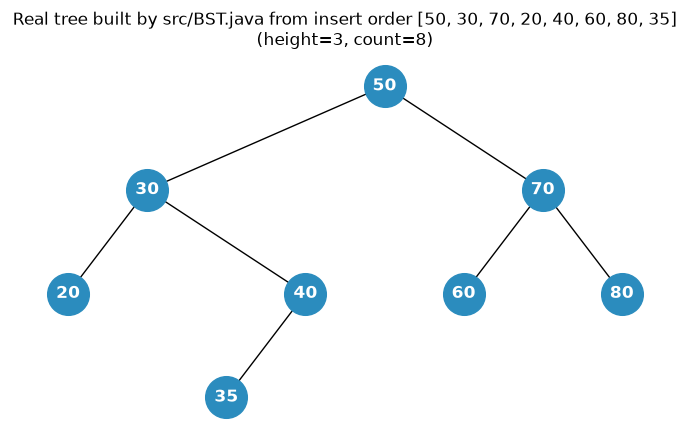

In [4]:
# In-order x-position, -depth y-position: the standard way to lay
# out a BST so it visually reads left-to-right in sorted order.
def bst_layout(structure, root):
    positions = {}
    x_counter = [0]

    def visit(val, depth):
        if val is None:
            return
        left, right = structure[val]
        visit(left, depth + 1)
        positions[val] = (x_counter[0], -depth)
        x_counter[0] += 1
        visit(right, depth + 1)

    visit(root, 0)
    return positions


def draw_bst(structure, root, title, filename):
    graph = nx.DiGraph()
    for val, (left, right) in structure.items():
        graph.add_node(val)
        if left is not None:
            graph.add_edge(val, left)
        if right is not None:
            graph.add_edge(val, right)

    pos = bst_layout(structure, root)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    nx.draw(
        graph, pos, ax=ax, with_labels=True, node_color="#2b8cbe",
        node_size=900, font_color="white", font_weight="bold", arrows=False,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=110)
    plt.show()


draw_bst(
    example["structure"], root=values[0],
    title=f"Real tree built by src/BST.java from insert order {values}\n(height={example['height']}, count={example['count']})",
    filename="example_tree.png",
)

This is the *exact* tree from the hand-trace earlier in the
tutorial, laid out automatically from the real `STRUCTURE:` dump that
`src/BST.java` prints after building it -- notice `35` sitting two levels
below the root under `40`, giving this particular tree a height of 3
(three edges on its longest root-to-leaf path, `50 -> 30 -> 40 -> 35`).

### Height vs. n: random insertion vs. sorted (worst-case) insertion

Now the real test of the "Going deeper" section's claim: build trees of
growing size $n$ two different ways -- values inserted in **random**
order vs. values inserted in **already-sorted** order -- and plot the
**real height** the compiled program reports for each.

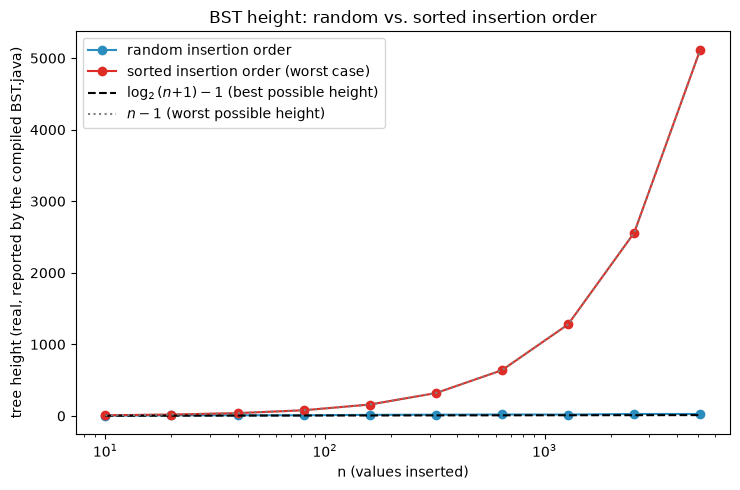

n=   10  random_height=   4  sorted_height=   9  log2(n)= 3.32
n=   20  random_height=   8  sorted_height=  19  log2(n)= 4.32
n=   40  random_height=   9  sorted_height=  39  log2(n)= 5.32
n=   80  random_height=   9  sorted_height=  79  log2(n)= 6.32
n=  160  random_height=  15  sorted_height= 159  log2(n)= 7.32
n=  320  random_height=  17  sorted_height= 319  log2(n)= 8.32
n=  640  random_height=  20  sorted_height= 639  log2(n)= 9.32
n= 1280  random_height=  19  sorted_height=1279  log2(n)=10.32
n= 2560  random_height=  27  sorted_height=2559  log2(n)=11.32
n= 5120  random_height=  27  sorted_height=5119  log2(n)=12.32


In [5]:
import random

random.seed(11)

sizes = [10, 20, 40, 80, 160, 320, 640, 1280, 2560, 5120]
random_heights = []
sorted_heights = []

for n in sizes:
    base = list(range(n))

    shuffled = base.copy()
    random.shuffle(shuffled)
    r = run_bst([f"I {v}" for v in shuffled], extra_java_args=["-Xss64m"])
    random_heights.append(r["height"])

    s = run_bst([f"I {v}" for v in base], extra_java_args=["-Xss64m"])
    sorted_heights.append(s["height"])

n_arr = np.array(sizes)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(sizes, random_heights, "o-", label="random insertion order", color="#2b8cbe")
ax.plot(sizes, sorted_heights, "o-", label="sorted insertion order (worst case)", color="#de2d26")
ax.plot(sizes, np.log2(n_arr + 1) - 1, "k--", label=r"$\log_2(n{+}1)-1$ (best possible height)")
ax.plot(sizes, n_arr - 1, color="gray", linestyle=":", label=r"$n-1$ (worst possible height)")
ax.set_xscale("log")
ax.set_xlabel("n (values inserted)")
ax.set_ylabel("tree height (real, reported by the compiled BST.java)")
ax.set_title("BST height: random vs. sorted insertion order")
ax.legend()
plt.tight_layout()
plt.savefig("height_vs_n.png", dpi=110)
plt.show()

for n, r, s in zip(sizes, random_heights, sorted_heights):
    print(f"n={n:5d}  random_height={r:4d}  sorted_height={s:4d}  log2(n)={np.log2(n):5.2f}")

**The random-order curve tracks $\log_2 n$ closely; the sorted-order
curve tracks $n - 1$ exactly** -- a straight line, i.e. a linked list, as
predicted in the "Going deeper" section. At $n = 5120$, a randomly-ordered
tree has height around 20, while a sorted-order tree has height 5119: a
search that takes on the order of 20 comparisons in one case takes over
5000 in the other, on a tree holding the *exact same 5120 values*.

One more real-world detail worth calling out: `run_bst` above passes
`-Xss64m` to the JVM (a larger-than-default stack size). That's not
cosmetic -- `BST.java`'s `insert`, `delete`, and `height` methods are all
written recursively (matching the recursive definitions in "Going
deeper"), and a recursive call per tree level means a degenerate,
$\Theta(n)$-height tree from sorted insertion needs $\Theta(n)$ stack
frames. At the default JVM stack size, building a several-thousand-node
sorted-order tree this way genuinely overflows the stack -- a very
concrete demonstration that $\Theta(n)$ height isn't just a theoretical
worst case, it's a shape that breaks real, running programs.

## Implementation

The reference implementation lives in
[`src/BST.java`](src/BST.java): a real Java class with `insert`, `search`,
`delete`, and `inOrder`, plus `height()` and `size()` for instrumentation.
`main()` reads one command per line from stdin (`I <v>` insert, `D <v>`
delete, `S <v>` search) and, after all commands are consumed, prints the
final in-order traversal, height, node count, and full tree structure --
the same output the Visuals section above already compiled and drove via
`subprocess`.

Now let's use that same compiled program to demonstrate deletion's three
cases (Case 1: leaf, Case 2: one child, Case 3: two children) with real
output, on the same 8-value tree from before.

In [6]:
# Rebuild the same tree, then delete one node of each shape in turn,
# printing the real structure after each step.
base_commands = [f"I {v}" for v in values]  # 50, 30, 70, 20, 40, 60, 80, 35

print("--- before any deletion ---")
before = run_bst(base_commands)
print("structure:", before["structure"])
print("height:", before["height"], " count:", before["count"])

print("\n--- Case 1: delete 20 (a leaf -- no children) ---")
after_case1 = run_bst(base_commands + ["D 20"])
print("structure:", after_case1["structure"])
print("in-order: ", after_case1["inorder"])
assert 20 not in after_case1["inorder"]
assert after_case1["inorder"] == sorted(v for v in values if v != 20)

print("\n--- Case 2: also delete 40 (one child -- only 35) ---")
after_case2 = run_bst(base_commands + ["D 20", "D 40"])
print("structure:", after_case2["structure"])
print("in-order: ", after_case2["inorder"])
# 35 should now hang directly off 30 in 40's old spot
assert after_case2["structure"][30] == (None, 35)

print("\n--- Case 3: also delete 50 (the root -- two children, 30 and 70) ---")
after_case3 = run_bst(base_commands + ["D 20", "D 40", "D 50"])
print("structure:", after_case3["structure"])
print("in-order: ", after_case3["inorder"])
assert after_case3["inorder"] == sorted(v for v in values if v not in (20, 40, 50))
new_root = [v for v in after_case3["structure"] if v not in
            {c for children in after_case3["structure"].values() for c in children if c is not None}][0]
print(f"\nnew root after deleting 50: {new_root}  (the in-order successor of 50 -- smallest value in 50's old right subtree)")

--- before any deletion ---


structure: {50: (30, 70), 30: (20, 40), 20: (None, None), 40: (35, None), 35: (None, None), 70: (60, 80), 60: (None, None), 80: (None, None)}
height: 3  count: 8

--- Case 1: delete 20 (a leaf -- no children) ---


structure: {50: (30, 70), 30: (None, 40), 40: (35, None), 35: (None, None), 70: (60, 80), 60: (None, None), 80: (None, None)}
in-order:  [30, 35, 40, 50, 60, 70, 80]

--- Case 2: also delete 40 (one child -- only 35) ---


structure: {50: (30, 70), 30: (None, 35), 35: (None, None), 70: (60, 80), 60: (None, None), 80: (None, None)}
in-order:  [30, 35, 50, 60, 70, 80]

--- Case 3: also delete 50 (the root -- two children, 30 and 70) ---


structure: {60: (30, 70), 30: (None, 35), 35: (None, None), 70: (None, 80), 80: (None, None)}
in-order:  [30, 35, 60, 70, 80]

new root after deleting 50: 60  (the in-order successor of 50 -- smallest value in 50's old right subtree)


Watch what happened in Case 3: deleting the root (`50`, with children
`30` and `70`) didn't remove the top of the tree at all -- it **replaced
50's value** with its in-order successor (`60`, the smallest value in
70's subtree), then removed 60's *original* leaf position. The tree stays
fully connected, the invariant holds everywhere, and every operation used
was one of the two simpler cases underneath -- exactly the correctness
argument from "Going deeper."

Finally, clean up the compiled class files (this repo doesn't keep build
artifacts on disk between runs -- they're gitignored and regenerated by
this exact `javac` step whenever the notebook re-executes):

In [7]:
import glob
import os

for class_file in glob.glob(str(src_dir / "*.class")):
    os.remove(class_file)
    print("removed:", class_file)

removed: src\BST$Node.class
removed: src\BST.class


## Use cases

- **In-memory ordered maps/sets with range queries.** Anywhere you need
  "give me everything between X and Y" or "give me all keys in sorted
  order" cheaply, a BST-shaped structure is the natural fit -- a hash
  table gives you neither, since hashing deliberately destroys order.
- **Standard library ordered containers.** `java.util.TreeMap` and
  `java.util.TreeSet` are ordered-map/set implementations built on a
  binary search tree -- but specifically a **red-black tree** (a
  self-balancing variant), not the plain, unbalanced BST built in this
  tutorial. That's a direct forward pointer to the Limitations section
  below: production ordered-map implementations essentially never skip
  the balancing step.
- **Symbol tables in compilers and interpreters.** Associating identifiers
  (variable/function names) with their declared type or scope information
  is a textbook ordered-map use case, and BST-family structures (again,
  usually balanced ones, or hash tables when order doesn't matter) are a
  standard choice.
- **The "20 questions" branching-decision idea, by name.** A decision tree
  in machine learning is structurally the same idea -- an internal node
  asks a yes/no (or threshold) question and routes left or right -- just
  with the question chosen to maximize information gain about a label,
  rather than "is this key smaller or bigger." Worth knowing as a naming
  and structural connection, not a claim that BSTs and decision trees
  solve the same problem.

## Limitations & debates

- **Worst-case $\Theta(n)$ height is a real production concern, not a
  theoretical curiosity.** The height-vs-n plot above measured it
  directly: sorted (or nearly-sorted, or adversarially chosen) insertion
  order degrades every operation from $O(\log n)$ to $O(n)$ on the exact
  same data a random insertion order would have handled in $O(\log n)$.
  Any system that inserts BST keys in an order an attacker or an upstream
  process could influence (timestamps, auto-incrementing IDs, already-
  sorted feed data) is exposed to this.
- **This is exactly why self-balancing variants exist and are what
  production libraries actually use.** AVL trees (strict height-balance
  invariant, more rotations) and red-black trees (looser balance
  invariant, fewer rotations, generally faster in practice) both
  guarantee $\Theta(\log n)$ height *regardless of insertion order*, at
  the cost of extra bookkeeping on every insert/delete. A plain,
  unbalanced BST like the one built here is rarely used unbalanced in
  serious systems for exactly this reason -- it's the right structure to
  *learn* the ideas on, not the one you'd reach for for production key-
  value ordering.
- **Deletion's two-children case is a common source of real bugs.** It's
  the one case that isn't a straightforward pointer splice: get the
  successor-selection or the recursive delete-from-subtree step wrong (for
  instance, deleting the successor's *value* instead of its *node*, or
  picking a "successor" that still has a left child) and the invariant
  silently breaks in a way that won't show up until a much later, unrelated
  search returns the wrong answer. Case 1 and Case 2 are close to
  impossible to get wrong; Case 3 deserves the explicit correctness
  argument given in "Going deeper," not "seemed to work in testing."
- **No operation is ever $O(1)$, not even in the best case.** Even search
  in a perfectly balanced BST is $O(\log n)$ -- there is no scenario where
  a BST beats a hash table's $O(1)$ average-case lookup. The reason to
  reach for a BST-family structure is never raw lookup speed; it's ordered
  iteration and range queries, which a hash table cannot do at all. Choose
  based on what operations you actually need, not on habit.

## References

- Knuth, D. E. *The Art of Computer Programming, Volume 3: Sorting and
  Searching*, 2nd ed. -- the classical treatment of binary search trees,
  their analysis, and balanced variants.
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed., Chapter 12 -- BST operations, the deletion cases, and the
  $O(h)$ complexity argument this tutorial follows.
- [`java.util.TreeMap` documentation](https://docs.oracle.com/en/java/javase/17/docs/api/java.base/java/util/TreeMap.html)
  -- explicitly documents its red-black tree implementation, i.e. a
  *self-balancing* BST, not a plain one.
- `src/BST.java` in this tutorial's folder -- the real, compiled
  implementation used for every measurement and diagram above.